In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# set_theme: 테마 지정
sns.set_theme(style="whitegrid")

# 폰트 깨짐 방지
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

---
## **실습 1 - 문자열 날짜를 시간으로 변환**
`글자로 읽힌 날짜를 진짜 시간 값으로 바꾸기`

In [3]:
# 샘플을 열고 시간 열의 자료형을 먼저 확인
df_1 = pd.read_csv("..\\Data\\20_engine01_timestamp_sample.csv")
print("shape:", df_1.shape)
df_1.info()

print()
print("변환 전 timestamp 타입:", df_1["timestamp"].dtype)
print("첫 값:", df_1["timestamp"].iloc[0], "/ 타입:", type(df_1["timestamp"].iloc[0]))

# 시간 변환 함수로 글자를 시간 값으로 바꾸기
df_1["timestamp"] = pd.to_datetime(df_1["timestamp"])

# 바뀐 자료형을 다시 확인해 변환 성공을 확인
print()
print("변환 후 timestamp 타입:", df_1["timestamp"].dtype)
print("첫 값:", df_1["timestamp"].iloc[0], "/ 타입:", type(df_1["timestamp"].iloc[0]))

# [확인]
# object(문자열) -> datetime64[ns]로 바뀌었다
# 문자열일 때는 그냥 글자라서 뺄셈도 정렬도 시간 의미로 안 되지만,
# datetime이 되면 .dt 접근자와 시간 인덱스 기능을 쓸 수 있게 된다
print()
print("시간끼리 뺄셈이 되는지 확인:", df_1["timestamp"].iloc[1] - df_1["timestamp"].iloc[0])

shape: (182, 6)
<class 'pandas.DataFrame'>
RangeIndex: 182 entries, 0 to 181
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  182 non-null    str    
 1   temp_out   182 non-null    float64
 2   temp_core  182 non-null    float64
 3   pressure   180 non-null    float64
 4   vibration  179 non-null    float64
 5   flow       182 non-null    float64
dtypes: float64(5), str(1)
memory usage: 8.7 KB

변환 전 timestamp 타입: str
첫 값: 2024-03-01 00:00:00 / 타입: <class 'str'>

변환 후 timestamp 타입: datetime64[us]
첫 값: 2024-03-01 00:00:00 / 타입: <class 'pandas.Timestamp'>

시간끼리 뺄셈이 되는지 확인: 0 days 01:00:00


---
## **실습 2 - 시간 조각 추출과 파생 열**
`변환한 시간 열에서 연, 월, 일, 시를 꺼내고 새 열 만들기`

In [4]:
df_2 = pd.read_csv("..\\Data\\20_engine01_timestamp_sample.csv")
df_2["timestamp"] = pd.to_datetime(df_2["timestamp"])

# 시간 접근자로 연, 월, 일, 시를 각각 꺼내 첫 값 확인
# .dt 는 datetime 타입에만 붙는 접근자
print("연:", df_2["timestamp"].dt.year.iloc[0])
print("월:", df_2["timestamp"].dt.month.iloc[0])
print("일:", df_2["timestamp"].dt.day.iloc[0])
print("시:", df_2["timestamp"].dt.hour.iloc[0])

# 시 조각을 새 열로 추가하기
df_2["hour"] = df_2["timestamp"].dt.hour

# 새 열의 앞부분을 확인해 시간대별 분석을 준비
print()
print("hour 앞 세 값:", df_2["hour"].head(3).tolist())
print()
print(df_2[["timestamp", "hour", "temp_out"]].head())

# 파생 열을 만들었으니 시간대별로 묶어볼 수 있다
print()
print("[시간대별 temp_out 평균 - 앞 6개]")
print(df_2.groupby("hour")["temp_out"].mean().round(2).head(6))

연: 2024
월: 3
일: 1
시: 0

hour 앞 세 값: [0, 1, 2]

            timestamp  hour  temp_out
0 2024-03-01 00:00:00     0    641.17
1 2024-03-01 01:00:00     1    640.66
2 2024-03-01 02:00:00     2    641.08
3 2024-03-01 03:00:00     3    641.18
4 2024-03-01 04:00:00     4    641.13

[시간대별 temp_out 평균 - 앞 6개]
hour
0    641.67
1    641.59
2    641.70
3    641.85
4    641.82
5    641.80
Name: temp_out, dtype: float64


---
## **실습 3 - 시간 인덱스 만들고 정렬**
`시간 열을 인덱스로 올리고 정렬해 분석 준비 완료`

In [6]:
df_3 = pd.read_csv("..\\Data\\20_engine01_timestamp_sample.csv")
df_3["timestamp"] = pd.to_datetime(df_3["timestamp"])

# 시간 열을 인덱스로 끌어올려 결과를 다시 담기
# set_index는 원본을 바꾸지 않고 새 객체를 돌려주므로 반드시 다시 대입해야 한다
df_3 = df_3.set_index("timestamp").sort_index()

# 인덱스 종류를 확인해 시간 인덱스인지 보기
print("인덱스 타입:", df_3.index.dtype)
print("인덱스 클래스:", type(df_3.index).__name__)

# 정렬 뒤 첫, 마지막 시각과 전체 행 수 확인
print()
print("첫 시각  :", df_3.index[0])
print("마지막 시각:", df_3.index[-1])
print("전체 행  :", len(df_3))

print()
print(df_3.head(3))

# [확인]
# 인덱스가 DatetimeIndex가 되면 df.loc["2024-03-02"] 같은 날짜 문자열 슬라이싱과
# resample() 같은 시간 전용 기능을 쓸 수 있게 된다

인덱스 타입: datetime64[us]
인덱스 클래스: DatetimeIndex

첫 시각  : 2024-03-01 00:00:00
마지막 시각: 2024-03-08 23:00:00
전체 행  : 182

                     temp_out  temp_core  pressure  vibration   flow
timestamp                                                           
2024-03-01 00:00:00    641.17    1399.16    554.91      47.28  8.344
2024-03-01 01:00:00    640.66    1399.28    553.06      47.06  8.385
2024-03-01 02:00:00    641.08    1394.97    554.32      47.18  8.436


---
## **실습 4 - 시간 인덱스로 기간 잘라보기**
`특정 날짜와 기간을 시간 인덱스로 골라내기`

In [7]:
df_4 = pd.read_csv("..\\Data\\20_engine01_timestamp_sample.csv")
df_4["timestamp"] = pd.to_datetime(df_4["timestamp"])
df_4 = df_4.set_index("timestamp").sort_index()

# 하루 날짜를 넣어 그 날 데이터만 선택
day_4 = df_4.loc["2024-03-02"]
print("2024-03-02 하루:", len(day_4), "행")

# 시작과 끝 날짜를 콜론으로 이어 기간 선택
# 시간 인덱스 슬라이싱은 리스트와 달리 "끝 날짜를 포함"한다
period_4 = df_4.loc["2024-03-05":"2024-03-07"]
print("2024-03-05 ~ 03-07:", len(period_4), "행")

# 각 결과의 행 수로 기간 크기 확인
print()
print("기간 첫 시각:", period_4.index[0])
print("기간 끝 시각:", period_4.index[-1], "<- 07일이 포함된 것 확인")

# 하루가 24행이 아닌 이유 - 빠진 시각이 있는지 확인
# date_range로 이론상 있어야 할 시각을 만들어 실제와 비교
print()
전체시각_4 = pd.date_range(df_4.index[0], df_4.index[-1], freq="1h")
print("이론상 시간 수:", len(전체시각_4))
print("실제 행 수    :", len(df_4))
print("빠진 시각     :", len(전체시각_4) - len(df_4), "개")
print()
print("[빠진 시각 목록]")
print(전체시각_4.difference(df_4.index))

# [확인]
# 하루가 24행이 아니라 20행인 이유, 사흘이 72행이 아니라 70행인 이유가 이것
# 센서 로그는 중간에 시각이 통째로 빠질 수 있어서 개수를 당연하게 믿으면 안 된다

2024-03-02 하루: 20 행
2024-03-05 ~ 03-07: 70 행

기간 첫 시각: 2024-03-05 00:00:00
기간 끝 시각: 2024-03-07 23:00:00 <- 07일이 포함된 것 확인

이론상 시간 수: 192
실제 행 수    : 182
빠진 시각     : 10 개

[빠진 시각 목록]
DatetimeIndex(['2024-03-01 10:00:00', '2024-03-01 11:00:00',
               '2024-03-02 01:00:00', '2024-03-02 16:00:00',
               '2024-03-02 17:00:00', '2024-03-02 18:00:00',
               '2024-03-04 05:00:00', '2024-03-04 18:00:00',
               '2024-03-06 00:00:00', '2024-03-06 01:00:00'],
              dtype='datetime64[us]', freq=None)


---
## **실습 5 - 시간 단위 평균, 최댓값 집계**
`리샘플링으로 단위를 바꿔 대표값 계산`

In [8]:
df_5 = pd.read_csv("..\\Data\\20_engine01_timestamp_sample.csv")
df_5["timestamp"] = pd.to_datetime(df_5["timestamp"])
df_5 = df_5.set_index("timestamp").sort_index()

# resample은 시간 인덱스가 있어야만 동작한다
# 1. 어떤 단위로 다시 묶을 것인가? -> 6시간
# 2. 새로 묶어서 통계낼 대상 컬럼은? -> temp_out
print("[원본 - 1시간 간격]")
print(df_5["temp_out"].head(3))

# 6시간 단위로 묶어 평균을 구하고 앞부분 확인
print()
print("[6시간 평균]")
print(df_5["temp_out"].resample("6h").mean().head(3).round(3))

# 같은 단위로 최댓값을 구해 평균과 비교
print()
print("[6시간 최댓값]")
print(df_5["temp_out"].resample("6h").max().head(3))

# 여러 통계를 한 번에 보려면 agg를 쓴다
print()
print("[6시간 단위 종합 - agg]")
print(df_5["temp_out"].resample("6h").agg(["mean", "max", "min", "median", "count"]).head(3).round(3))

# 최댓값이 평균보다 큼을 수치로 확인
mean_5 = df_5["temp_out"].resample("6h").mean()
max_5 = df_5["temp_out"].resample("6h").max()
print()
print("첫 구간 평균:", round(mean_5.iloc[0], 3), "| 최댓값:", max_5.iloc[0])
print("모든 구간에서 최댓값 >= 평균 인가?:", (max_5 >= mean_5).all())

[원본 - 1시간 간격]
timestamp
2024-03-01 00:00:00    641.17
2024-03-01 01:00:00    640.66
2024-03-01 02:00:00    641.08
Name: temp_out, dtype: float64

[6시간 평균]
timestamp
2024-03-01 00:00:00    641.058
2024-03-01 06:00:00    641.005
2024-03-01 12:00:00    640.953
Freq: 6h, Name: temp_out, dtype: float64

[6시간 최댓값]
timestamp
2024-03-01 00:00:00    641.18
2024-03-01 06:00:00    641.27
2024-03-01 12:00:00    641.23
Freq: 6h, Name: temp_out, dtype: float64

[6시간 단위 종합 - agg]
                        mean     max     min   median  count
timestamp                                                   
2024-03-01 00:00:00  641.058  641.18  640.66  641.130      6
2024-03-01 06:00:00  641.005  641.27  640.84  640.955      4
2024-03-01 12:00:00  640.953  641.23  640.71  640.935      6

첫 구간 평균: 641.058 | 최댓값: 641.18
모든 구간에서 최댓값 >= 평균 인가?: True


---
## **실습 6 - 리샘플링 단위와 데이터 성김**
`묶는 단위를 바꿔 다운샘플링 효과를 체험`

원본 행 수: 182

1h   ->  192행
6h   ->   32행
12h  ->   16행
1D   ->    8행


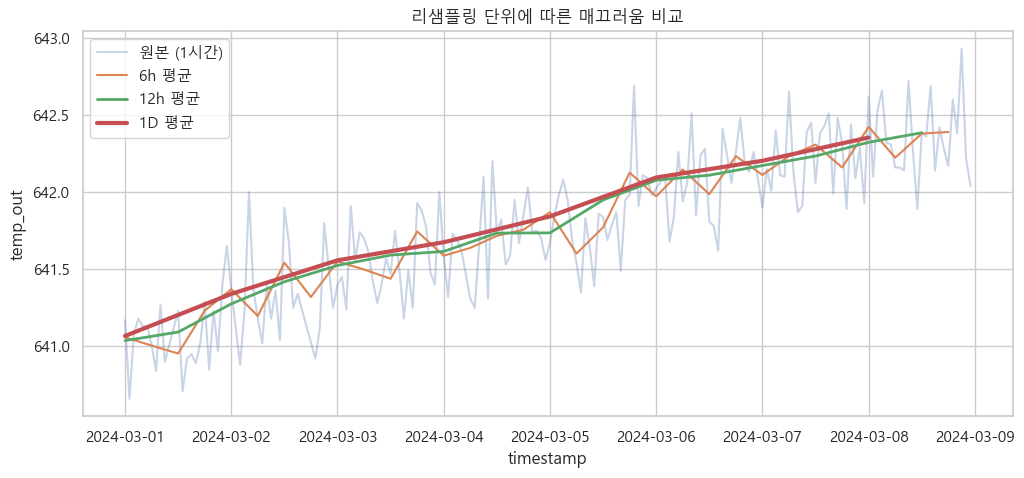

1h 리샘플 후 NaN 개수: 10


In [9]:
df_6 = pd.read_csv("..\\Data\\20_engine01_timestamp_sample.csv")
df_6["timestamp"] = pd.to_datetime(df_6["timestamp"])
df_6 = df_6.set_index("timestamp").sort_index()

# 한 시간, 6시간, 12시간 단위로 각각 묶어 평균 구하기
# 각 결과의 행 수를 세어 비교
print("원본 행 수:", len(df_6))
print()
for unit in ["1h", "6h", "12h", "1D"]:
    결과 = df_6["temp_out"].resample(unit).mean()
    print(f"{unit:4} -> {len(결과):4}행")

# 단위가 클수록 행 수가 줄어 흐름이 매끄러워짐을 확인
plt.figure(figsize=(12, 5))
plt.title("리샘플링 단위에 따른 매끄러움 비교")
plt.plot(df_6.index, df_6["temp_out"], alpha=0.3, label="원본 (1시간)")
for unit, width in [("6h", 1.5), ("12h", 2), ("1D", 3)]:
    결과 = df_6["temp_out"].resample(unit).mean()
    plt.plot(결과.index, 결과.values, linewidth=width, label=f"{unit} 평균")
plt.xlabel("timestamp")
plt.ylabel("temp_out")
plt.legend()
plt.show()

# [확인]
# 6h 32행, 12h 16행, 1D 8행으로 단위가 커질수록 점이 줄고 선이 매끄러워진다
# 다만 1h는 192행으로 원본 182행보다 오히려 늘어난다
# -> resample이 빠진 10개 시각을 NaN 자리로 채워 넣기 때문 (실습 4에서 확인한 그 10개)
print("1h 리샘플 후 NaN 개수:", df_6["temp_out"].resample("1h").mean().isna().sum())

---
## **실습 7 - 일별 집계로 추세 확인**
`일별 평균으로 잡음을 걸러 추세를 원본과 겹쳐 확인`

[일별 평균]
timestamp
2024-03-01    641.07
2024-03-02    641.34
2024-03-03    641.56
2024-03-04    641.68
2024-03-05    641.84
2024-03-06    642.10
2024-03-07    642.20
2024-03-08    642.35
Freq: D, Name: temp_out, dtype: float64


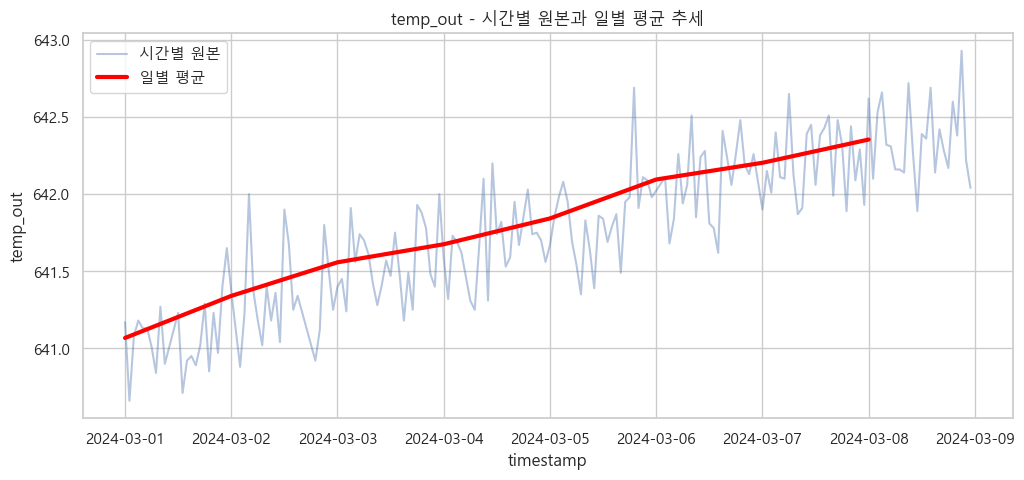


첫날 평균 641.07 -> 마지막날 평균 642.35 (상승, 변화량 +1.29)
매일 전날보다 높았는가?: True


In [10]:
df_7 = pd.read_csv("..\\Data\\20_engine01_timestamp_sample.csv")
df_7["timestamp"] = pd.to_datetime(df_7["timestamp"])
df_7 = df_7.set_index("timestamp").sort_index()

# 하루 단위 평균을 구하고 앞부분 확인
daily_7 = df_7["temp_out"].resample("1D").mean()
print("[일별 평균]")
print(daily_7.round(2))

# 원본을 옅게, 일별 평균을 진하게 겹쳐 그리기
plt.figure(figsize=(12, 5))
plt.title("temp_out - 시간별 원본과 일별 평균 추세")
plt.plot(df_7.index, df_7["temp_out"], alpha=0.4, label="시간별 원본")
plt.plot(daily_7.index, daily_7.values, linewidth=3, color="red", label="일별 평균")
plt.xlabel("timestamp")
plt.ylabel("temp_out")
plt.legend()
plt.show()

# 첫날과 마지막날 평균을 비교해 추세 방향 판정
첫날_7 = daily_7.iloc[0]
끝날_7 = daily_7.iloc[-1]
방향_7 = "상승" if 끝날_7 > 첫날_7 else "하강"
print()
print(f"첫날 평균 {첫날_7:.2f} -> 마지막날 평균 {끝날_7:.2f} ({방향_7}, 변화량 {끝날_7 - 첫날_7:+.2f})")

# 두 점만 보지 말고 8일 내내 단조 증가인지도 확인
print("매일 전날보다 높았는가?:", (daily_7.diff().dropna() > 0).all())

# [확인]
# 시간별 원본은 위아래로 튀어서 방향이 안 보이지만,
# 일별 평균은 641.07 -> 642.35로 8일 내내 한 번도 안 꺾이고 상승했다
# 이게 잡음을 걷어내고 추세만 남기는 다운샘플링의 목적

---
## **실습 8 - 업샘플링 결측과 보간**
`촘촘하게 만들 때 생기는 결측과 원본 결측을 보간으로 채우기`

In [12]:
df_8 = pd.read_csv("..\\Data\\20_engine01_timestamp_sample.csv")
df_8["timestamp"] = pd.to_datetime(df_8["timestamp"])
df_8 = df_8.set_index("timestamp").sort_index()

# 30분 단위로 촘촘하게 만들어 생긴 결측 세기
# 원본이 1시간 간격인데 30분으로 쪼개면 사이사이가 빈 칸이 된다
up_8 = df_8["flow"].resample("30min").mean()
print("[업샘플링 결과 앞부분]")
print(up_8.head())

print()
print("업샘플링 후 전체 길이:", len(up_8))
print("업샘플링 결측:", up_8.isna().sum())

# 보간으로 빈 값을 채우고 결측이 0이 됨을 확인
# interpolate는 앞뒤 값을 잇는 직선 위에서 중간값을 계산해 채운다
채움_8 = up_8.interpolate()
print("보간 후 결측:", 채움_8.isna().sum())

print()
print("[보간 전후 비교 - 앞 5개]")
print(pd.DataFrame({"보간전": up_8, "보간후": 채움_8.round(4)}).head())

# 원본에 원래 있던 결측도 보간으로 메우기
print()
print("[원본 컬럼별 결측]")
print(df_8.isna().sum())

for col in ["vibration", "pressure"]:
    전_8 = df_8[col].isna().sum()
    후_8 = df_8[col].interpolate().isna().sum()
    print(f"{col:10} 보간 전 {전_8}개 -> 보간 후 {후_8}개")

[업샘플링 결과 앞부분]
timestamp
2024-03-01 00:00:00    8.344
2024-03-01 00:30:00      NaN
2024-03-01 01:00:00    8.385
2024-03-01 01:30:00      NaN
2024-03-01 02:00:00    8.436
Freq: 30min, Name: flow, dtype: float64

업샘플링 후 전체 길이: 383
업샘플링 결측: 201
보간 후 결측: 0

[보간 전후 비교 - 앞 5개]
                       보간전     보간후
timestamp                         
2024-03-01 00:00:00  8.344  8.3440
2024-03-01 00:30:00    NaN  8.3645
2024-03-01 01:00:00  8.385  8.3850
2024-03-01 01:30:00    NaN  8.4105
2024-03-01 02:00:00  8.436  8.4360

[원본 컬럼별 결측]
temp_out     0
temp_core    0
pressure     2
vibration    3
flow         0
dtype: int64
vibration  보간 전 3개 -> 보간 후 0개
pressure   보간 전 2개 -> 보간 후 0개
